# 04 · El barrido: ¿aportan algo los datos sintéticos?

## El diseño experimental

Esta es la gráfica que el profesor calificó de imprescindible: el error del modelo downstream **frente al número de
datos reales**, con **una curva por cantidad de datos sintéticos**, y **un panel por generador**.

Una celda del experimento es una tupla `(semilla, generador, n_real, n_synth)` y se ejecuta así:

1. se submuestrean `n_real` ventanas reales de train, **manteniendo la proporción de clases**;
2. se añaden `n_synth` ventanas sintéticas **de la clase minoritaria**, todas con etiqueta 1;
3. se entrena la arquitectura congelada **desde cero**;
4. se ajusta el umbral de decisión en el conjunto de validación **real** y se evalúa en el de test **real**.

La rejilla es `n_real ∈ {500, 1000, 2000, 4000, todos}` × `n_synth ∈ {0, 250, 500, 1000, 2000}` × 7 generadores ×
3 semillas, unas **450 celdas**.

## Los invariantes que hacen honesta la comparación

- **La arquitectura no cambia nunca.** Es el instrumento de medida.
- **Validación y test son 100% reales en todas las celdas.** No entra ni una ventana sintética.
- **Los generadores se ajustan una vez por semilla** con las ventanas minoritarias de train, y de cada uno se extrae
  un único *pool* de 2000 muestras del que los `n_synth` menores son prefijos. Así las curvas no se contaminan con
  ruido de muestreo entre puntos de la rejilla (es lo que hace el profesor con `X_train_aux_synth[0:1000]`).
- **`n_synth = 0` no depende del generador**, así que se calcula una vez por `(semilla, n_real)` y se comparte.
- **Cada celda guarda su curva de loss en disco**, para que todo número reportado tenga detrás una prueba de
  convergencia.

## Por qué submuestreamos al azar y no cogemos los datos más recientes

Coger las últimas `n_real` ventanas sería más realista ("un analista con poco histórico"), pero cambiaría **el
periodo histórico a la vez que el tamaño de muestra**: una caída del error podría ser escasez o podría ser otro
régimen de mercado. Submuestrear sobre todo el bloque de entrenamiento aísla el efecto que queremos medir.

## Un efecto secundario que hay que declarar

Al añadir solo minoritarios, la proporción de clases del entrenamiento se distorsiona: con `n_real = 500` y
`n_synth = 2000`, el 82% del conjunto es clase positiva. Las métricas de **ranking** como el PR-AUC son robustas a
eso (no dependen de la calibración de la probabilidad, solo del orden), lo que es una razón más para haberla
elegido como métrica principal. Pero conviene tenerlo presente al mirar la precisión y el recall, que sí dependen
del umbral.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config, data, plots, sweep

resultados = sweep.load_results()
print(f"Celdas ejecutadas: {len(resultados)}")
print(f"Semillas: {sorted(resultados['seed'].unique())}")
print(f"n_real: {sorted(resultados['n_real'].dropna().unique())} (+ 'todos')")
print(f"n_synth: {sorted(resultados['n_synth'].unique())}")
print(f"Generadores: {sorted(resultados['generator'].unique())}")
print(f"\nTiempo total de cómputo: {resultados['segundos'].sum()/60:.0f} min")

Celdas ejecutadas: 375
Semillas: [np.int64(0), np.int64(1), np.int64(2)]
n_real: [np.float64(500.0), np.float64(1000.0), np.float64(2000.0), np.float64(4000.0)] (+ 'todos')
n_synth: [np.int64(0), np.int64(250), np.int64(500), np.int64(1000), np.int64(2000)]
Generadores: ['autoregresivo', 'gan', 'gaussiano', 'ruido', 'sin_sinteticos', 'student_t', 'vae']

Tiempo total de cómputo: 118 min


## Comprobación de que el barrido hizo lo que dijimos

Antes de interpretar nada, verificamos los invariantes sobre la tabla de resultados: los tamaños de entrenamiento
son los esperados y la distorsión de la proporción de clases es la que anticipábamos.

In [3]:
chequeo = (resultados
    .assign(n_real=lambda d: d["n_real"].fillna(-1))
    .groupby(["n_real", "n_synth"])
    .agg(n_celdas=("test_pr_auc", "size"),
         n_train=("n_train", "mean"),
         tasa_pos_train=("tasa_positivos_train", "mean"),
         epocas=("epocas", "mean"))
    .round(3))
display(chequeo)

n_celdas  n_train  tasa_pos_train  epocas
n_real  n_synth                                           
-1.0    0               3  11336.0           0.050  22.000
        250            18  11586.0           0.071  21.389
        500            18  11836.0           0.090  21.222
        1000           18  12336.0           0.127  21.278
        2000           18  13336.0           0.192  21.056
 500.0  0               3    500.0           0.050  53.667
        250            18    750.0           0.367  30.389
        500            18   1000.0           0.525  25.333
        1000           18   1500.0           0.683  23.722
        2000           18   2500.0           0.810  23.167
 1000.0 0               3   1000.0           0.050  38.000
        250            18   1250.0           0.240  27.500
        500            18   1500.0           0.367  24.722
        1000           18   2000.0           0.525  25.333
        2000           18   3000.0           0.683  24.889
 2000.0 0               3   2000.0           0.050  28.667
        250            18   2250.0           0.156  26.389
        500            18   2500.0           0.240  23.778
        1000           18   3000.0           0.367  24.833
        2000           18   4000.0           0.525  24.778
 4000.0 0               3   4000.0           0.050  25.667
        250            18   4250.0           0.106  23.333
        500            18   4500.0           0.156  22.778
        1000           18   5000.0           0.240  21.889
        2000           18   6000.0           0.367  21.667

## TSTR: sólo con sintéticos

Antes de mirar la mezcla, la prueba más agresiva es entrenar **únicamente con sintéticos** y evaluar contra
reales. Es la métrica canónica en la literatura de series temporales sintéticas (*train on synthetic, test on
real*, TSTR): si un generador captura lo que importa para la tarea, su TSTR se acerca al techo de "todo real"; si
no lo captura, cae en picado. Reutilizamos los pools sintéticos ya ajustados (uno por semilla y generador) y
entrenamos la CNN con 2000 minoritarios sintéticos más 2000 mayoritarios construidos escalando esos mismos
sintéticos para que su vol de cartera caiga por debajo del umbral. No entra ni una ventana real en el train.

In [ ]:
from src import experiments, data, plots

split, _, _ = data.load_problem()
tstr = experiments.tstr_table(split, seeds=(0, 1, 2), n_synth=2000)
resumen = (
    tstr.groupby("generator")[["val_pr_auc", "test_pr_auc"]]
        .agg(["mean", "std"])
        .round(3)
)
# Reordenar en el mismo orden que el resto del notebook
resumen = resumen.reindex([g for g in plots.GEN_ORDER if g in resumen.index])
display(resumen)

## La gráfica principal

Un panel por generador (los siete del notebook 03). En negro, la referencia: **sin sintéticos**. Las barras de
error son el error estándar sobre las 3 semillas.

Lo que hay que buscar, y que es lo que el profesor anticipó en clase:

- con **pocos datos reales**, hueco entre las curvas de colores y la negra: ahí los sintéticos aportan;
- con **muchos datos reales**, las curvas se juntan o se cruzan: ya no hay nada que aportar, y añadir sintéticos
  puede incluso perjudicar;
- y los **generadores que reproducen la vol de cartera** (ruido y factor de mercado) marcando la referencia difícil
  de batir para los modelos sofisticados. Es una confirmación del argumento del notebook 03.

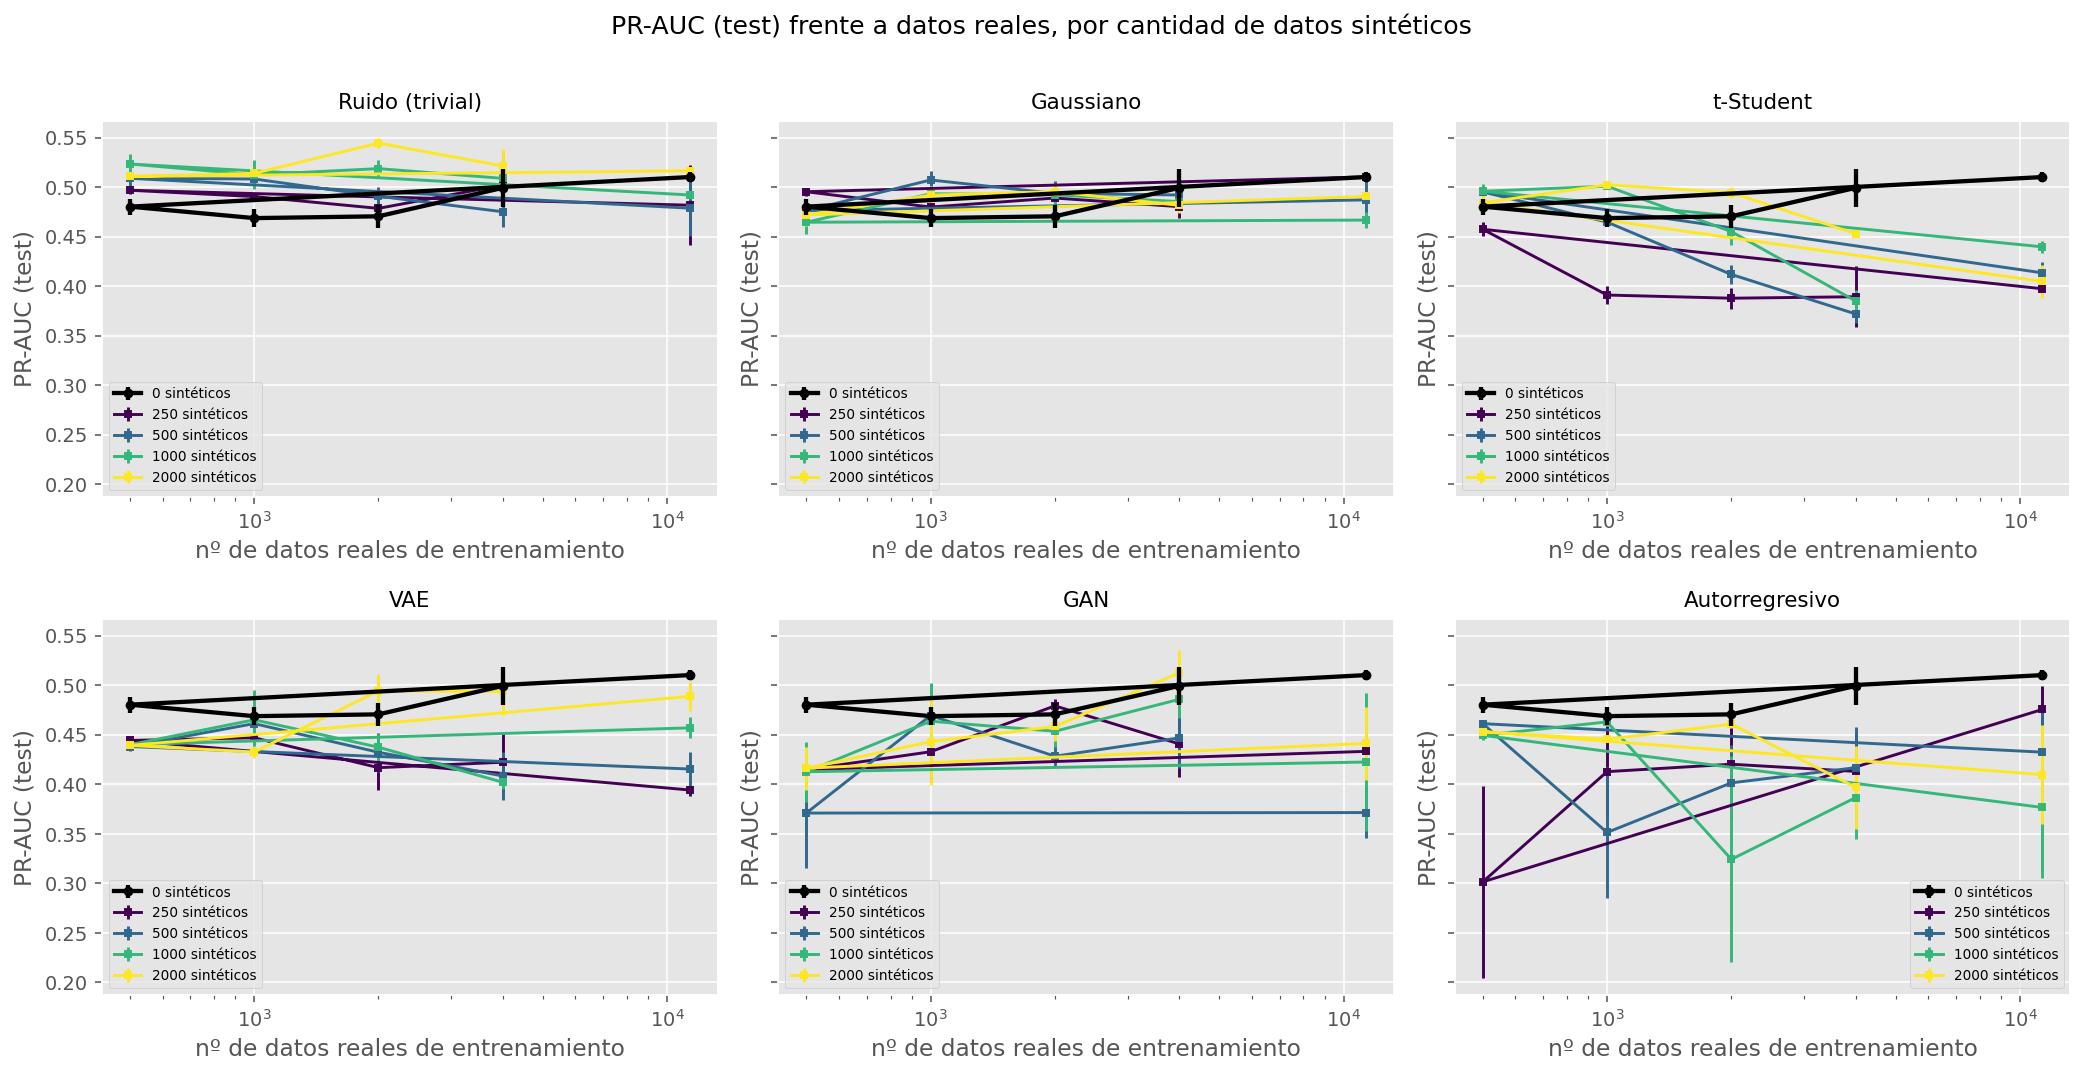

In [4]:
fig = plots.plot_sweep_per_generator(resultados, metric="test_pr_auc")
display(Image(str(fig)))

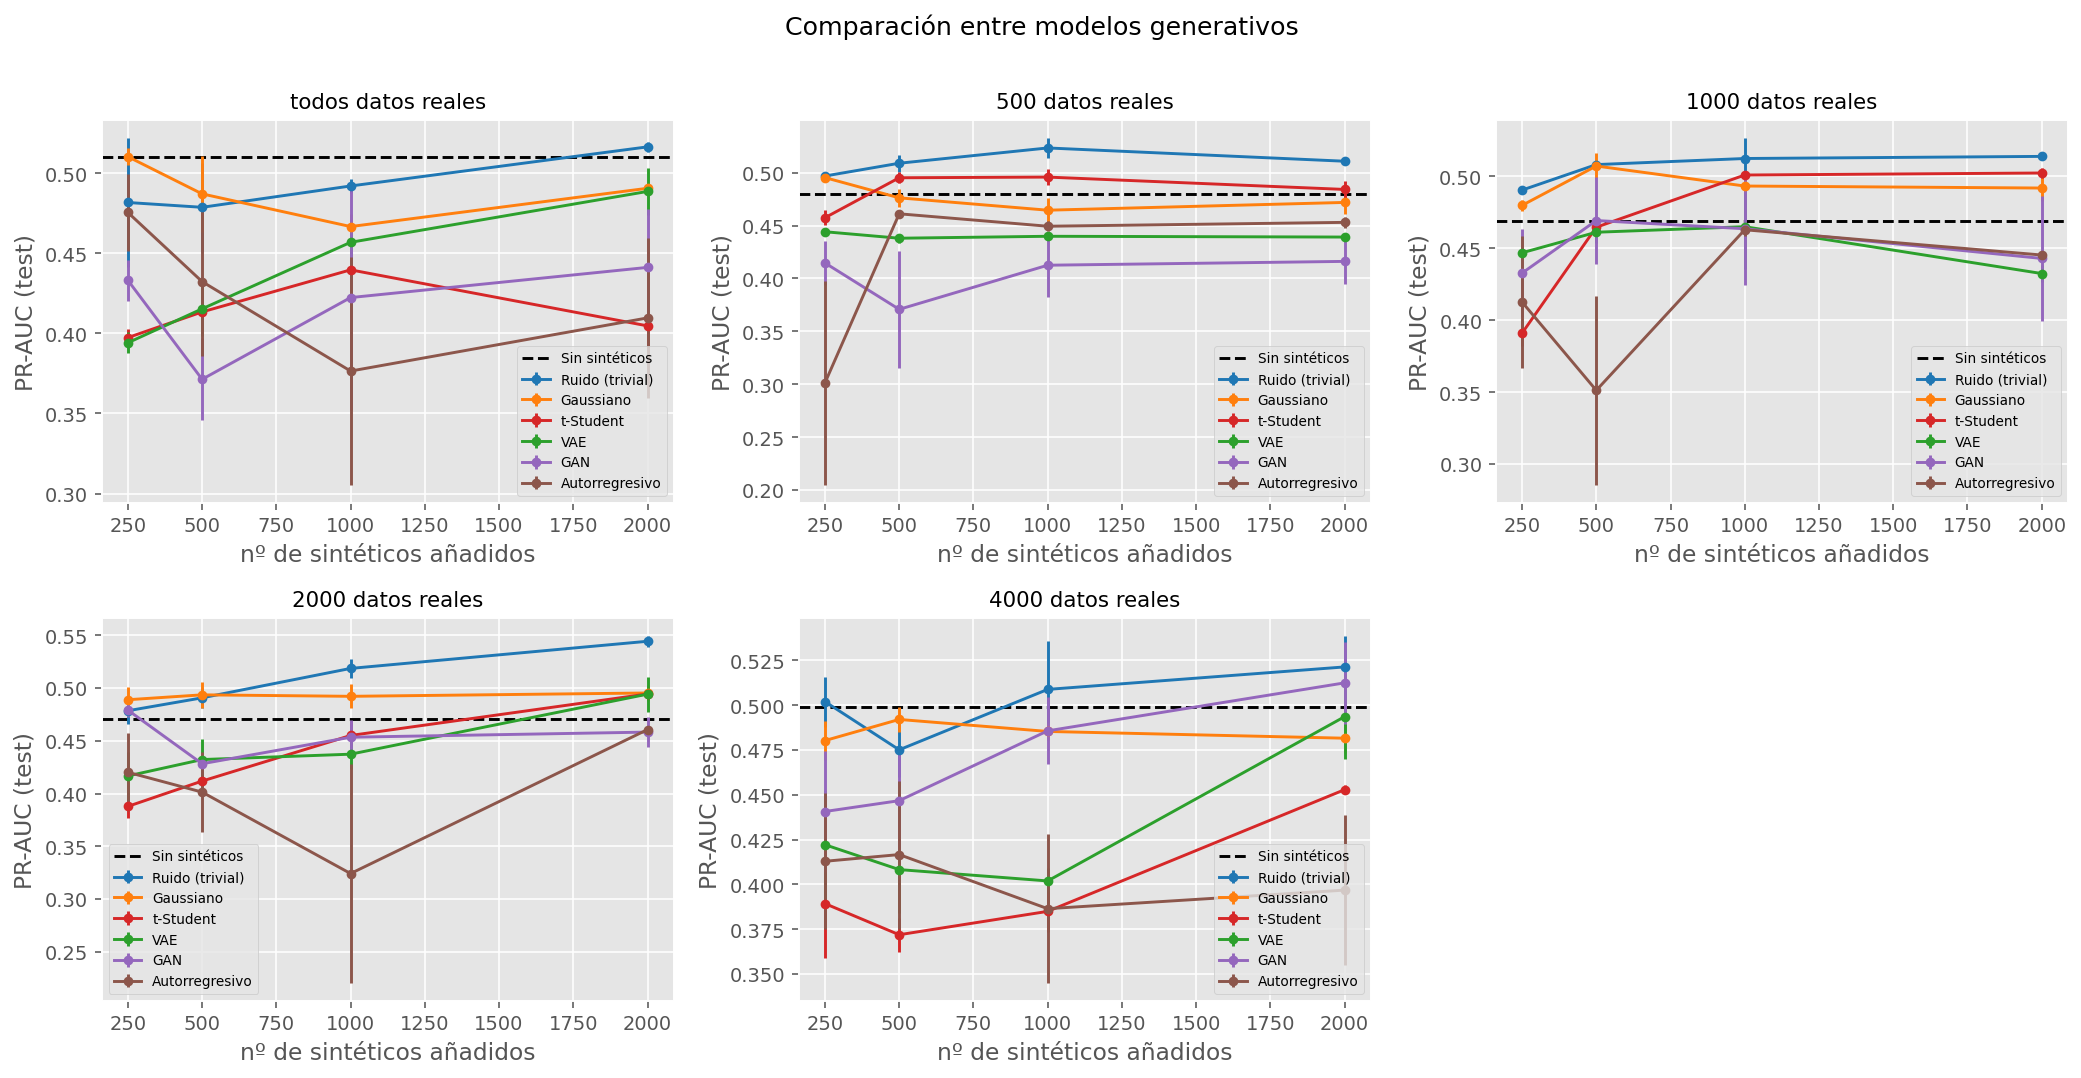

In [5]:
fig = plots.plot_sweep_generator_comparison(resultados, metric="test_pr_auc")
display(Image(str(fig)))

## La misma historia en números

Media sobre semillas del PR-AUC en test. La fila `sin_sinteticos` es la referencia de cada columna.

In [6]:
tabla = (resultados
    .assign(n_real=lambda d: d["n_real"].fillna(-1).astype(int))
    .pivot_table(index=["generator", "n_synth"], columns="n_real",
                 values="test_pr_auc", aggfunc="mean")
    .rename(columns=lambda c: "todos" if c == -1 else str(c)))
orden = [g for g in plots.GEN_ORDER if g in tabla.index.get_level_values(0)]
display(tabla.loc[orden].round(3))

n_real                  todos    500   1000   2000   4000
generator      n_synth                                   
sin_sinteticos 0        0.510  0.480  0.469  0.471  0.499
ruido          250      0.482  0.497  0.490  0.479  0.502
               500      0.479  0.509  0.508  0.491  0.475
               1000     0.492  0.523  0.512  0.519  0.509
               2000     0.516  0.511  0.514  0.544  0.521
gaussiano      250      0.510  0.495  0.480  0.489  0.480
               500      0.487  0.476  0.507  0.494  0.492
               1000     0.467  0.465  0.493  0.492  0.485
               2000     0.491  0.472  0.492  0.495  0.482
student_t      250      0.397  0.457  0.391  0.388  0.389
               500      0.413  0.495  0.465  0.412  0.372
               1000     0.440  0.496  0.501  0.455  0.385
               2000     0.405  0.484  0.502  0.494  0.453
vae            250      0.394  0.444  0.447  0.417  0.422
               500      0.415  0.438  0.461  0.432  0.408
               1000     0.457  0.440  0.465  0.437  0.402
               2000     0.489  0.439  0.432  0.494  0.494
gan            250      0.433  0.415  0.433  0.479  0.441
               500      0.371  0.371  0.469  0.428  0.447
               1000     0.422  0.413  0.464  0.453  0.486
               2000     0.441  0.416  0.443  0.458  0.512
autoregresivo  250      0.476  0.301  0.413  0.420  0.413
               500      0.432  0.461  0.351  0.401  0.417
               1000     0.376  0.449  0.463  0.324  0.386
               2000     0.410  0.453  0.445  0.461  0.397

## Ganancia relativa frente a no usar sintéticos

Para cada combinación de generador y cantidad de datos reales, la mejor ganancia relativa que consigue **alguna**
cantidad de sintéticos. En rojo, los casos en los que los datos sintéticos ayudaron.

Advertencia honesta de lectura: coger el mejor `n_synth` a posteriori es una forma de selección, así que estos
números son un **techo optimista** de lo que se conseguiría eligiendo `n_synth` a ciegas. Los tratamos como
"¿existe alguna cantidad de sintéticos que ayude?", no como una estimación sin sesgo de la mejora esperable.

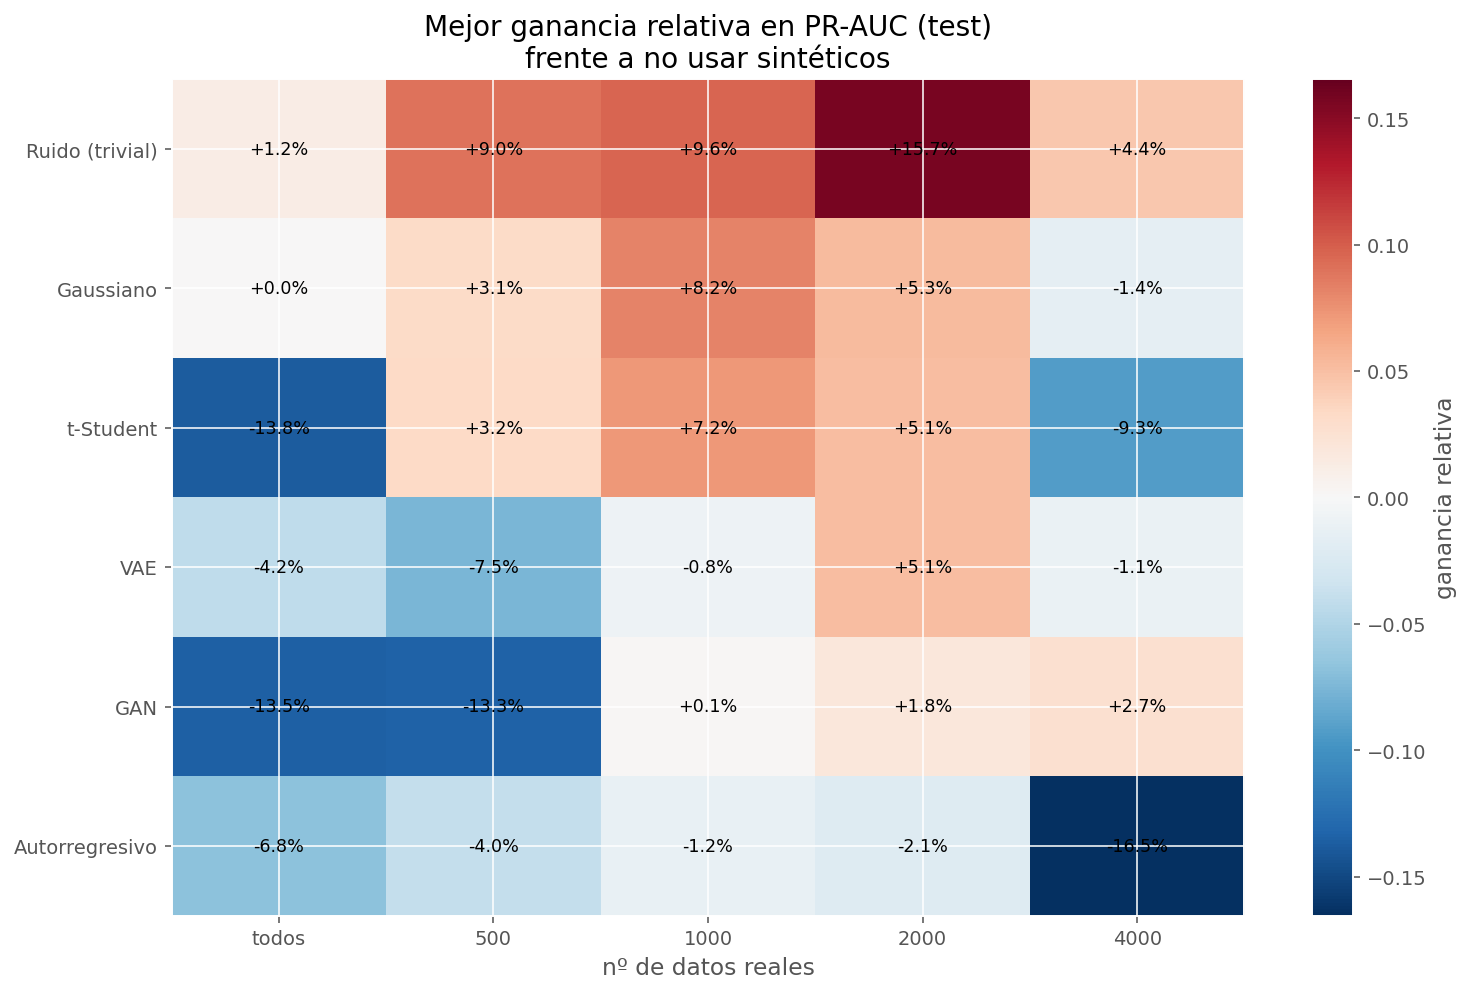

In [7]:
fig = plots.plot_gain_heatmap(resultados, metric="test_pr_auc")
display(Image(str(fig)))